## Overview
This model implements a U-Net style architecture to obtain a binary segmentation mask to identify the portion of the image that is a fish and the portion that is not.

## Imports

In [1]:
import os
from glob import glob
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import Binarizer
import tensorflow as tf
from tensorflow.data import Dataset, AUTOTUNE
from tensorflow.keras.models import Model
from tensorflow.keras.utils import plot_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Input, Conv2D, Conv2DTranspose, MaxPool2D, SpatialDropout2D, Concatenate, LeakyReLU

## Constants

In [2]:
RANDOM_STATE = 7
IMAGE_SIZE = (384, 512)
VAL_SPLIT = 0.1
BATCH_SIZE = 64
SHUFFLE_BUFFER = 400
LR_ALPHA = 0.3
LEARNING_RATE = 1e-4
EPOCHS = 25
PLOTS_DPI = 150
PATIENCE = 3

## Data Loading

### Loading all image file paths

In [3]:
all_train_files = glob("../input/a-large-scale-fish-dataset/Fish_Dataset/Fish_Dataset/*/*/*.png")
train_gt_files = glob("../input/a-large-scale-fish-dataset/Fish_Dataset/Fish_Dataset/*/* GT/*.png")
train_image_files = list(set(all_train_files) - set(train_gt_files))

train_image_files = np.array(sorted(train_image_files))
train_gt_files = np.array(sorted(train_gt_files))

len(train_image_files), len(train_gt_files)

(9000, 9000)

### Splitting the data into train and validation datasets

In [4]:
X_train, X_val, y_train, y_val = train_test_split(train_image_files, train_gt_files, test_size = VAL_SPLIT)

train_ds = Dataset.from_tensor_slices((X_train, y_train))
val_ds = Dataset.from_tensor_slices((X_val, y_val))

train_ds, val_ds

(<TensorSliceDataset shapes: ((), ()), types: (tf.string, tf.string)>,
 <TensorSliceDataset shapes: ((), ()), types: (tf.string, tf.string)>)

### Create `tf.data.Dataset` object for loading images for training and validation

In [5]:
def load_images(original_file, gt_file):

    original_img = tf.io.read_file(original_file)
    original_img = tf.io.decode_png(original_img, channels = 3)
    original_img = tf.image.resize(original_img, IMAGE_SIZE)
    
    gt_img = tf.io.read_file(gt_file)
    gt_img = tf.io.decode_png(gt_img, channels = 1)
    gt_img = tf.image.resize(gt_img, IMAGE_SIZE)
    
    return original_img/255.0, gt_img/255.0

train_dataset = train_ds.shuffle(SHUFFLE_BUFFER, seed = RANDOM_STATE) \
                        .map(load_images, num_parallel_calls = AUTOTUNE) \
                        .batch(BATCH_SIZE, drop_remainder = True) \
                        .prefetch(buffer_size = AUTOTUNE)
    
val_dataset = val_ds.map(load_images, num_parallel_calls = AUTOTUNE) \
                    .batch(BATCH_SIZE, drop_remainder = True) \
                    .prefetch(buffer_size = AUTOTUNE)

train_dataset, val_dataset

(<PrefetchDataset shapes: ((64, 384, 512, 3), (64, 384, 512, 1)), types: (tf.float32, tf.float32)>,
 <PrefetchDataset shapes: ((64, 384, 512, 3), (64, 384, 512, 1)), types: (tf.float32, tf.float32)>)

### Sample data points

#### Training dataset

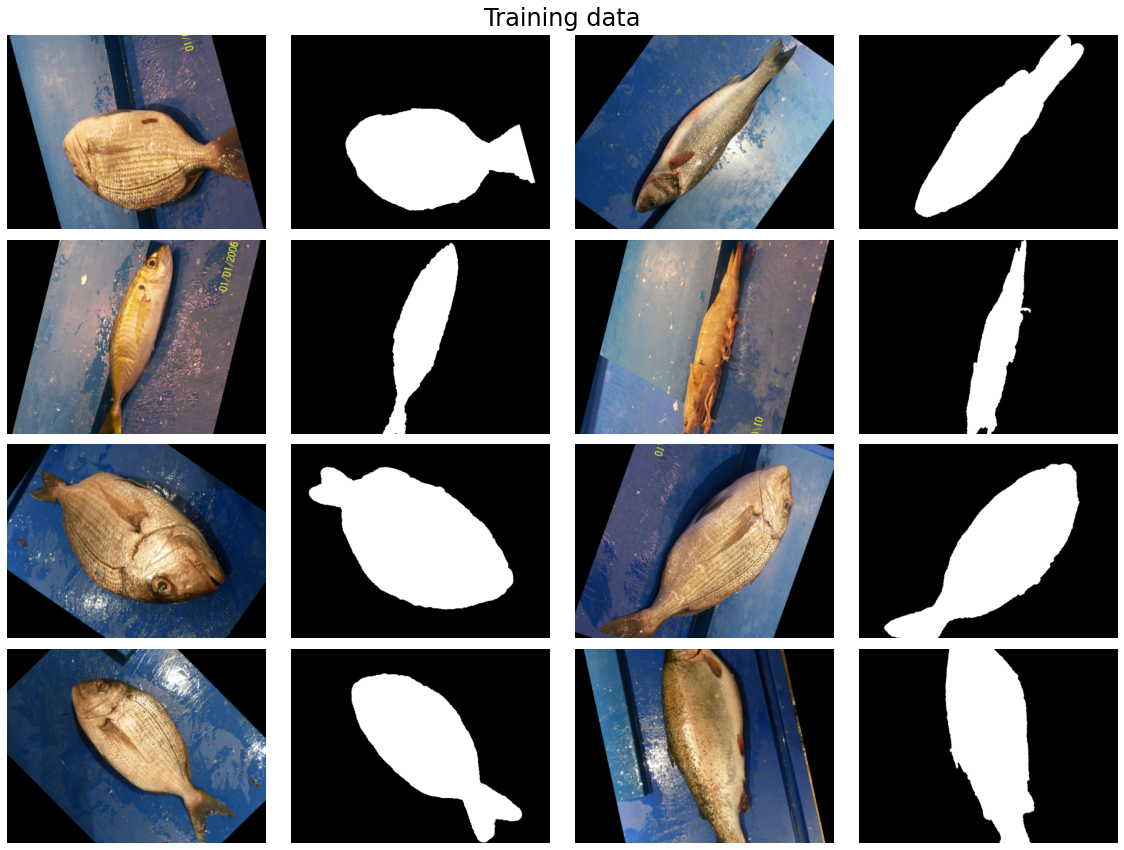

In [6]:
sample_images = [i for i  in train_dataset.take(1)][0]

fig, axes = plt.subplots(4, 4,figsize = (16, 12))
axes = axes.flatten()

for i in range(8):    
    axes[i * 2].imshow(sample_images[0][i].numpy())
    axes[i * 2].grid(False)
    axes[i * 2].axis(False)
    
    axes[(i * 2) + 1].imshow(sample_images[1][i].numpy(), cmap = 'gray')
    axes[(i * 2) + 1].grid(False)
    axes[(i * 2) + 1].axis(False)
    
plt.suptitle("Training data", fontsize = 24)
plt.tight_layout()
plt.show()

#### Validation dataset

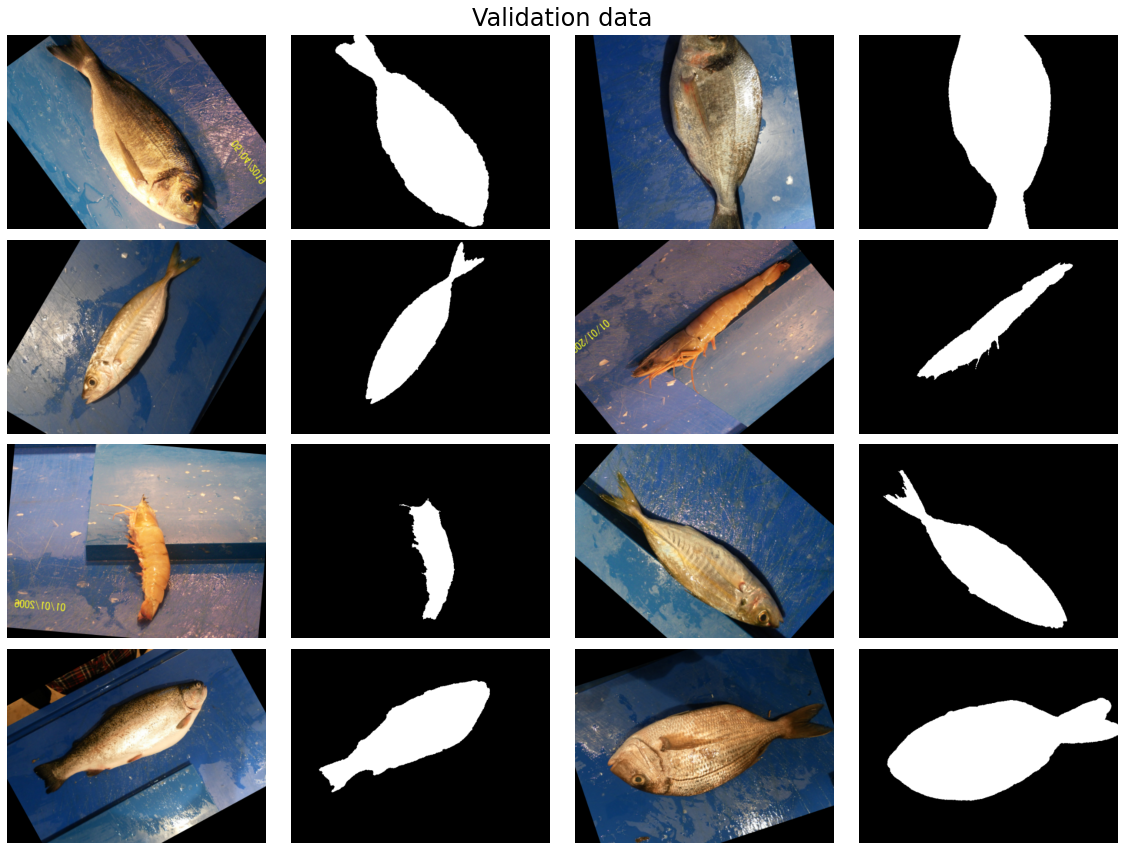

In [7]:
sample_images = [i for i  in val_dataset.take(1)][0]

fig, axes = plt.subplots(4, 4,figsize = (16, 12))
axes = axes.flatten()

for i in range(8):    
    axes[i * 2].imshow(sample_images[0][i].numpy())
    axes[i * 2].grid(False)
    axes[i * 2].axis(False)
    
    axes[(i * 2) + 1].imshow(sample_images[1][i].numpy(), cmap = 'gray')
    axes[(i * 2) + 1].grid(False)
    axes[(i * 2) + 1].axis(False)
    
plt.suptitle("Validation data", fontsize = 24)
plt.tight_layout()
plt.show()

## Model Building

### Model design and summary

In [8]:
def unet_model():
    input_layer = Input(shape = (*IMAGE_SIZE, 3), name = 'Input_Layer')
    
    conv_1 = Conv2D(8, 5, padding = 'same', activation = LeakyReLU(LR_ALPHA), name = 'Conv_1')(input_layer)
    pool_1 = MaxPool2D(name = 'Max_Pool_1')(conv_1)
    conv_2 = Conv2D(16, 5, padding = 'same', activation = LeakyReLU(LR_ALPHA), name = 'Conv_2')(pool_1)
    pool_2 = MaxPool2D(name = 'Max_Pool_2')(conv_2)
    spd_1 = SpatialDropout2D(0.1, name = 'SPD_1')(pool_2)
    
    conv_3 = Conv2D(32, 4, padding = 'same', activation = LeakyReLU(LR_ALPHA), name = 'Conv_3')(spd_1)
    pool_3 = MaxPool2D(name = 'Max_Pool_3')(conv_3)
    conv_4 = Conv2D(64, 4, padding = 'same', activation = LeakyReLU(LR_ALPHA), name = 'Conv_4')(pool_3)
    pool_4 = MaxPool2D(name = 'Max_Pool_4')(conv_4)
    spd_2 = SpatialDropout2D(0.1, name = 'SPD_2')(pool_4)
    
    conv_5 = Conv2D(128, 3, padding = 'same', activation = LeakyReLU(LR_ALPHA), name = 'Conv_5')(spd_2)
    pool_5 = MaxPool2D(name = 'Max_Pool_5')(conv_5)
    conv_6 = Conv2D(256, 3, padding = 'same', activation = LeakyReLU(LR_ALPHA), name = 'Conv_6')(pool_5)
    pool_7 = MaxPool2D(name = 'Max_Pool_6')(conv_6)
    spd_3 = SpatialDropout2D(0.1, name = 'SPD_3')(pool_7)
    
    conv_7 = Conv2D(512, 2, padding = 'same', activation = LeakyReLU(LR_ALPHA), name = 'Conv_7')(spd_3)
    pool_7 = MaxPool2D(name = 'Max_Pool_7')(conv_7)
    
    conv_t_1 = Conv2DTranspose(256, 2, padding = 'same', strides = 2, activation = LeakyReLU(LR_ALPHA), name = 'Conv_T_1')(pool_7)
    concat_1 = Concatenate(name = 'Concat_1')([conv_t_1, spd_3])
    spd_4 = SpatialDropout2D(0.1, name = 'SPD_4')(concat_1)
    
    conv_t_2 = Conv2DTranspose(128, 3, padding = 'same', strides = 2, activation = LeakyReLU(LR_ALPHA), name = 'Conv_T_2')(spd_4)
    conv_t_3 = Conv2DTranspose(64, 3, padding = 'same', strides = 2, activation = LeakyReLU(LR_ALPHA), name = 'Conv_T_3')(conv_t_2)
    concat_2 = Concatenate(name = 'Concat_2')([conv_t_3, spd_2])
    spd_5 = SpatialDropout2D(0.1, name = 'SPD_5')(concat_2)
    
    conv_t_4 = Conv2DTranspose(32, 4, padding = 'same', strides = 2, activation = LeakyReLU(LR_ALPHA), name = 'Conv_T_4')(spd_5)
    conv_t_5 = Conv2DTranspose(16, 4, padding = 'same', strides = 2, activation = LeakyReLU(LR_ALPHA), name = 'Conv_T_5')(conv_t_4)
    concat_3 = Concatenate(name = 'Concat_3')([conv_t_5, spd_1])
    spd_6 = SpatialDropout2D(0.1, name = 'SPD_6')(concat_3)
    
    conv_t_6 = Conv2DTranspose(8, 5, padding = 'same', strides = 2, activation = LeakyReLU(LR_ALPHA), name = 'Conv_T_6')(spd_6)
    conv_t_7 = Conv2DTranspose(1, 5, padding = 'same', strides = 2, activation = 'sigmoid', name = 'Conv_T_7')(conv_t_6)    
    
    return Model(inputs = input_layer, outputs = conv_t_7, name = 'Fish_Segmentation')
                 
model = unet_model()
model.compile(optimizer = Adam(LEARNING_RATE), loss = 'binary_crossentropy', metrics = ['accuracy'])
model.summary()

Model: "Fish_Segmentation"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
Input_Layer (InputLayer)        [(None, 384, 512, 3) 0                                            
__________________________________________________________________________________________________
Conv_1 (Conv2D)                 (None, 384, 512, 8)  608         Input_Layer[0][0]                
__________________________________________________________________________________________________
Max_Pool_1 (MaxPooling2D)       (None, 192, 256, 8)  0           Conv_1[0][0]                     
__________________________________________________________________________________________________
Conv_2 (Conv2D)                 (None, 192, 256, 16) 3216        Max_Pool_1[0][0]                 
__________________________________________________________________________________

### Schematic Diagram

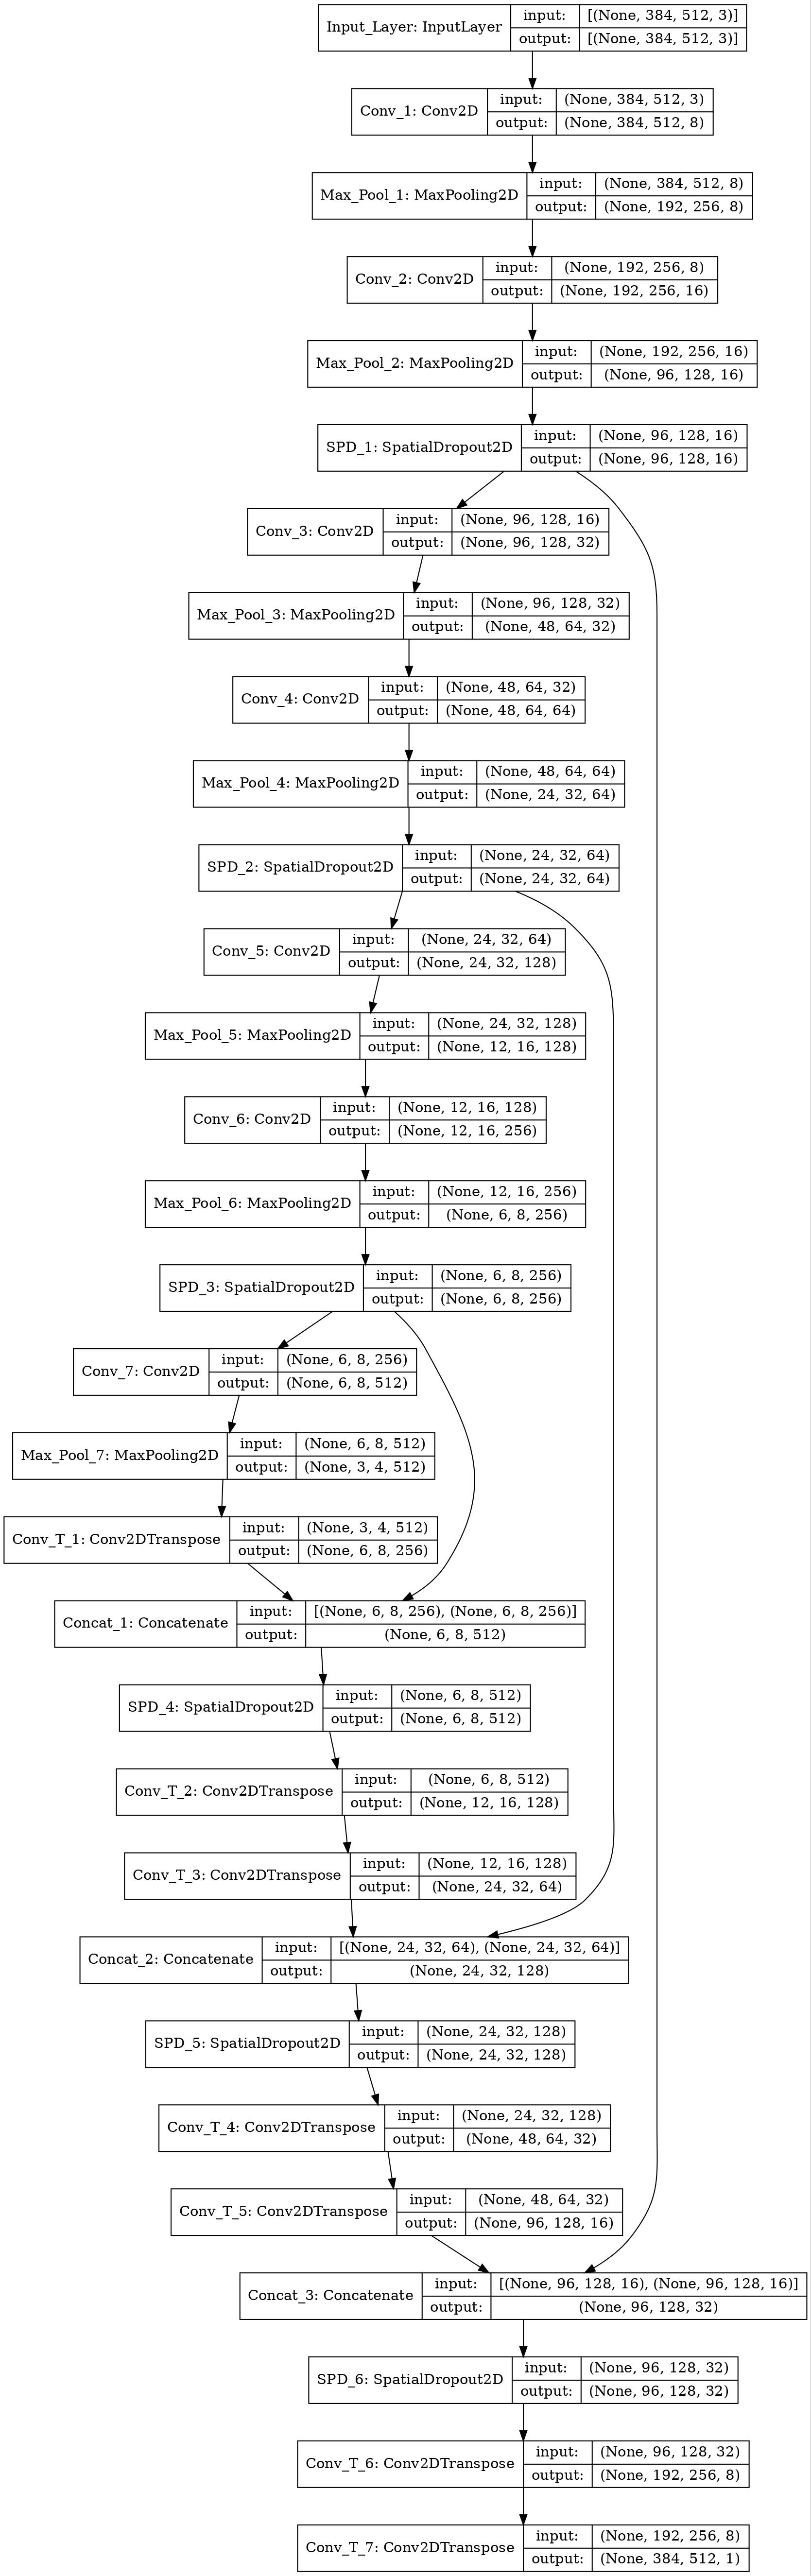

In [9]:
plot_model(model, to_file = 'model.jpg', show_shapes = True, dpi = PLOTS_DPI)

## Model training

In [10]:
%%time

early_stop = EarlyStopping(monitor = 'val_loss', patience = PATIENCE, restore_best_weights = True)

history = model.fit(
    train_dataset,
    epochs = EPOCHS,
    validation_data = val_dataset,
    callbacks = [early_stop]
)

Epoch 1/25
126/126 [==============================] - 149s 1s/step - loss: 0.6291 - accuracy: 0.7221 - val_loss: 0.2206 - val_accuracy: 0.9202
Epoch 2/25
126/126 [==============================] - 88s 695ms/step - loss: 0.1651 - accuracy: 0.9423 - val_loss: 0.1012 - val_accuracy: 0.9573
Epoch 3/25
126/126 [==============================] - 88s 702ms/step - loss: 0.0938 - accuracy: 0.9627 - val_loss: 0.0708 - val_accuracy: 0.9693
Epoch 4/25
126/126 [==============================] - 90s 712ms/step - loss: 0.0777 - accuracy: 0.9679 - val_loss: 0.0652 - val_accuracy: 0.9717
Epoch 5/25
126/126 [==============================] - 90s 713ms/step - loss: 0.0735 - accuracy: 0.9695 - val_loss: 0.0634 - val_accuracy: 0.9715
Epoch 6/25
126/126 [==============================] - 89s 708ms/step - loss: 0.0690 - accuracy: 0.9709 - val_loss: 0.0584 - val_accuracy: 0.9738
Epoch 7/25
126/126 [==============================] - 88s 702ms/step - loss: 0.0658 - accuracy: 0.9722 - val_loss: 0.0563 - val_accu

## Model Evaluation

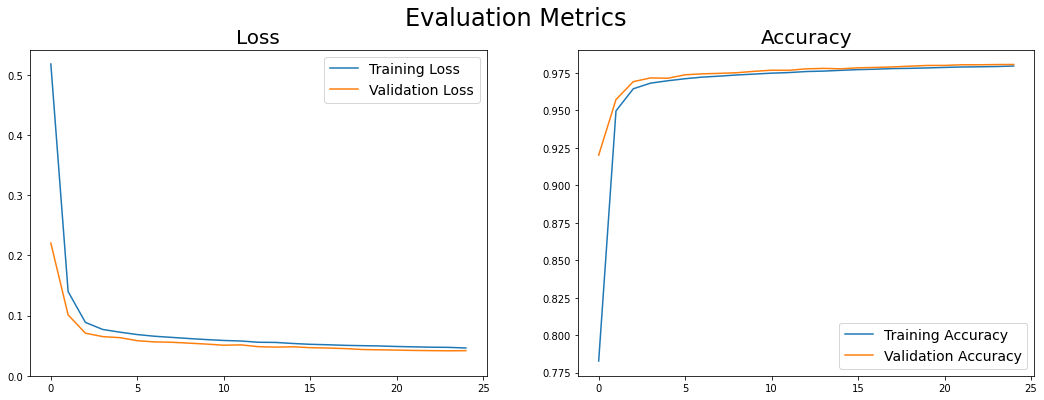

In [11]:
loss = history.history['loss']
val_loss = history.history['val_loss']

accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

epochs_range = history.epoch

plt.figure(figsize = (18, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, loss, label = 'Training Loss')
plt.plot(epochs_range, val_loss, label = 'Validation Loss')
plt.legend(loc = 'upper right', fontsize = 14)
plt.ylim(0, None)
plt.title('Loss', fontsize = 20)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, accuracy, label = 'Training Accuracy')
plt.plot(epochs_range, val_accuracy, label = 'Validation Accuracy')
plt.legend(loc = 'lower right', fontsize = 14)
plt.title('Accuracy', fontsize = 20)

plt.suptitle("Evaluation Metrics", fontsize = 24)
plt.savefig('loss_and_accuracy.jpg', dpi = PLOTS_DPI, bbox_inches = 'tight')
plt.show()

## Predictions

### Loading file paths for test images

In [12]:
all_test_files = np.array(glob("../input/a-large-scale-fish-dataset/NA_Fish_Dataset/*/*"))

len(all_test_files)

430

### Sample test data points and get predictions and binary mask

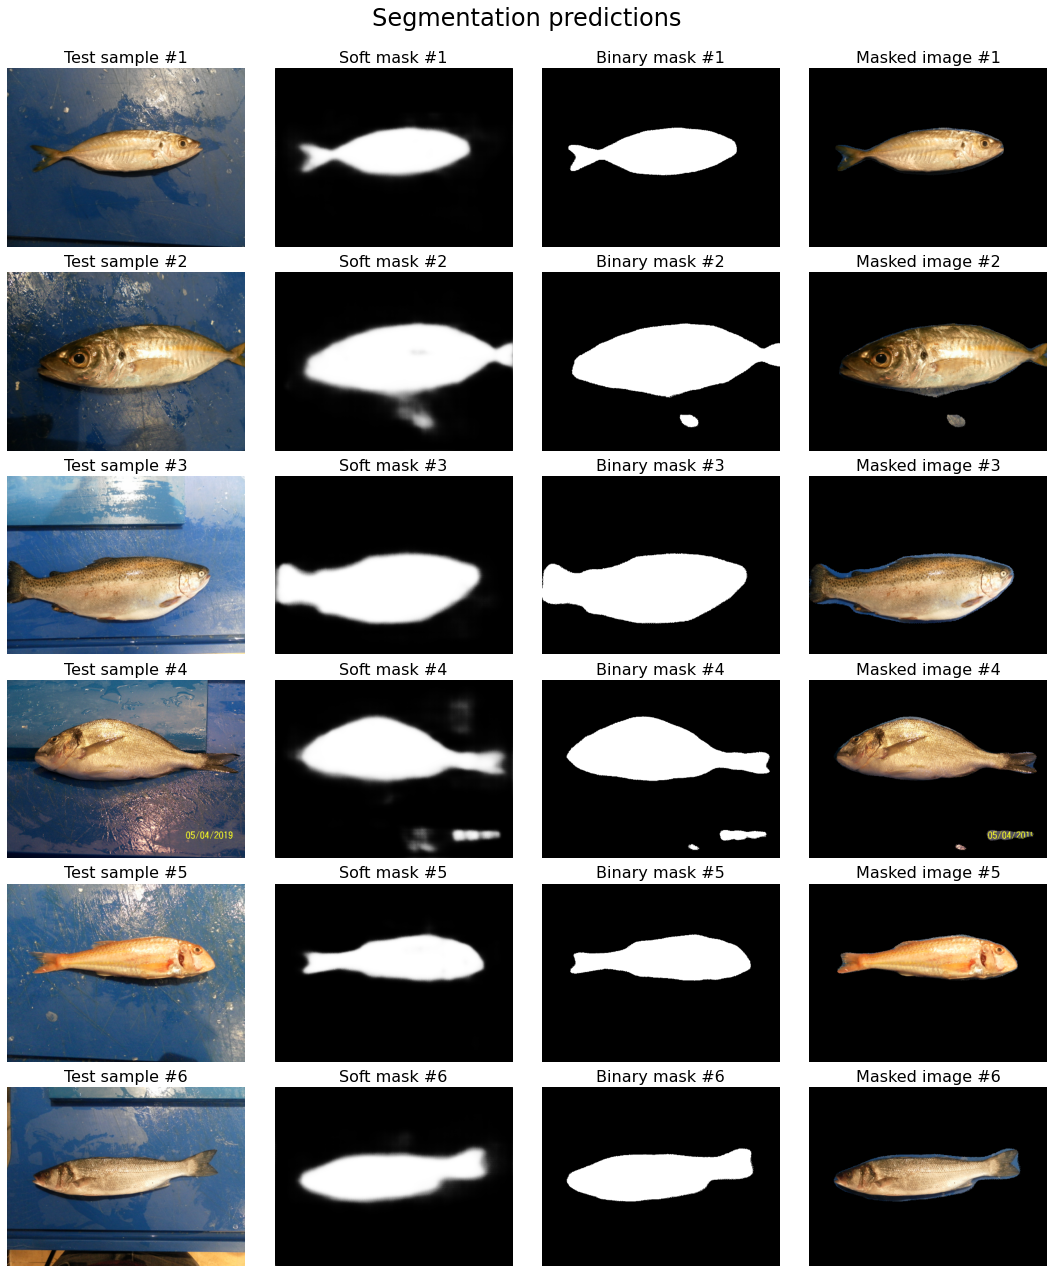

In [13]:
def load_test_image(filepath):
    img = tf.io.read_file(filepath)
    img = tf.io.decode_png(img, channels = 3)
    img = tf.image.resize(img, IMAGE_SIZE)
    return img/255.0

rnd_index = np.random.randint(len(all_test_files), size = 6)
pred_imgs = []

for i in rnd_index:
    pred_imgs.append(load_test_image(all_test_files[i]))
    
pred = model.predict(np.array(pred_imgs))
pred_mask = Binarizer(threshold = 0.5).transform(pred.reshape(-1, 1)).reshape(pred.shape)

fig, axes = plt.subplots(6, 4,figsize = (15, 18))
axes = axes.flatten()

for i in range(6):    
    axes[i * 4].imshow(pred_imgs[i])
    axes[i * 4].grid(False)
    axes[i * 4].axis(False)
    axes[i * 4].set_title(f"Test sample #{i + 1}", fontsize = 16)
    
    axes[(i * 4) + 1].imshow(pred[i], cmap = 'gray')
    axes[(i * 4) + 1].grid(False)
    axes[(i * 4) + 1].axis(False)
    axes[(i * 4) + 1].set_title(f"Soft mask #{i + 1}", fontsize = 16)
    
    axes[(i * 4) + 2].imshow(pred_mask[i], cmap = 'gray')
    axes[(i * 4) + 2].grid(False)
    axes[(i * 4) + 2].axis(False)
    axes[(i * 4) + 2].set_title(f"Binary mask #{i + 1}", fontsize = 16)
    
    axes[(i * 4) + 3].imshow(pred_imgs[i] * pred_mask[i])
    axes[(i * 4) + 3].grid(False)
    axes[(i * 4) + 3].axis(False)
    axes[(i * 4) + 3].set_title(f"Masked image #{i + 1}", fontsize = 16)
    
plt.suptitle("Segmentation predictions", fontsize = 24)
plt.tight_layout(rect = [0, 0, 1, 0.98])
plt.savefig('predictions.jpg', dpi = PLOTS_DPI, bbox_inches = 'tight')
plt.show()